#### Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Load data and explore

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.shape

(13320, 9)

In [5]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


#### Data Cleaning and Feature Engineering

In [7]:
df = df.drop(columns = ["area_type", "availability", "society", "balcony"])

In [8]:
#check for missing values
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [9]:
#drop missing rows
df = df.dropna()

In [10]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [11]:
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [12]:
df["bedroom"] = df["size"].str.split(" ").str[0].astype(int)

In [13]:
df = df.drop(columns = "size")

In [14]:
df["total_sqft"].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [15]:
def convert_sqft_to_mean(value):
    try:
        if '-' in value: 
            nums = list(map(float, value.split('-')))  
            return np.mean(nums)  
        return float(value)  
    except ValueError:  
        return None

In [16]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_mean)

In [17]:
df.loc[30]

location      Yelahanka
total_sqft       2475.0
bath                4.0
price             186.0
bedroom               4
Name: 30, dtype: object

In [18]:
df.isnull().sum()

location       0
total_sqft    46
bath           0
price          0
bedroom        0
dtype: int64

- total_sqft consist values like 34.46Sq. Meter, 34.46Sq. yards e.t.c, which I would delete

In [19]:
df = df.dropna()

In [20]:
df.isnull().sum()

location      0
total_sqft    0
bath          0
price         0
bedroom       0
dtype: int64

In [21]:
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]

In [22]:
df.head()

,location,total_sqft,bath,price,bedroom,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000


In [23]:
len(df["location"].unique())

1298

In [24]:
df["location"] = df["location"].apply(lambda x: x.strip())

In [25]:
location_stats = df.groupby("location")["location"].agg("count").sort_values(ascending = False)

In [26]:
location_stats

location
Whitefield               533
Sarjapur  Road           392
Electronic City          304
Kanakpura Road           264
Thanisandra              235
                        ... 
1 Giri Nagar               1
Kanakapura Road,           1
Kanakapura main  Road      1
Kannur                     1
whitefiled                 1
Name: location, Length: 1287, dtype: int64

In [27]:
len(location_stats[location_stats < 10])

1033

In [28]:
location_stats_less_than_10 = location_stats[location_stats < 10]

In [29]:
location_stats_less_than_10 

location
Kaverappa Layout         9
B Narayanapura           9
2nd Phase JP Nagar       9
Banagiri Nagar           9
Chandra Layout           9
                        ..
1 Giri Nagar             1
Kanakapura Road,         1
Kanakapura main  Road    1
Kannur                   1
whitefiled               1
Name: location, Length: 1033, dtype: int64

In [30]:
len(df["location"].unique())

1287

In [31]:
df["location"] = df["location"].apply(lambda x: "other" if x in location_stats_less_than_10 else x)

In [32]:
len(df["location"].unique())

255

In [33]:
df.head(10)

,location,total_sqft,bath,price,bedroom,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,1310.0,3.0,63.25,3,4828.244275
9,other,1020.0,6.0,370.00,6,36274.509804


#### Outlier Detection and Removal

In [34]:
df[df["total_sqft"] / df["bedroom"] < 300].head()

,location,total_sqft,bath,price,bedroom,price_per_sqft
9,other,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,1407.0,4.0,150.0,6,10660.980810
68,Devarachikkanahalli,1350.0,7.0,85.0,8,6296.296296
70,other,500.0,3.0,100.0,3,20000.000000


In [35]:
len(df[df["total_sqft"] / df["bedroom"] < 300])

744

In [36]:
df.shape

(13200, 6)

In [37]:
df = df[~(df["total_sqft"] / df["bedroom"] < 300)]

In [38]:
df.shape

(12456, 6)

In [39]:
df['price_per_sqft'].describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [40]:
def remove_outliers(df):
    Q1 = df['price_per_sqft'].quantile(0.25)  
    Q3 = df['price_per_sqft'].quantile(0.75) 
    IQR = Q3 - Q1  # Interquartile Range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df['price_per_sqft'] >= lower_bound) & (df['price_per_sqft'] <= upper_bound)]

df= remove_outliers(df)
df.shape

(11453, 6)

In [41]:
df['price_per_sqft'].describe()

count    11453.000000
mean      5413.464008
std       1758.555400
min        267.829813
25%       4123.711340
50%       5100.483092
75%       6412.478336
max      10967.098704
Name: price_per_sqft, dtype: float64

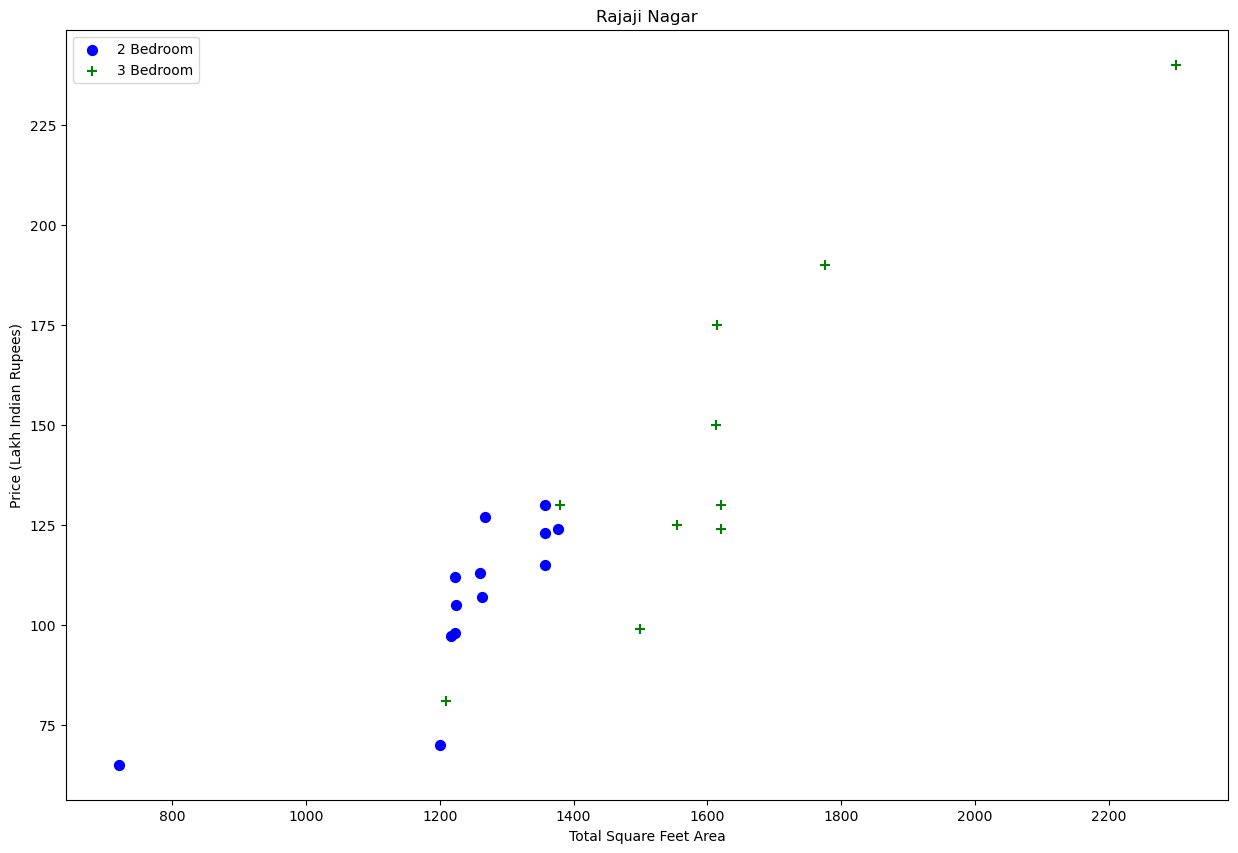

In [42]:
import matplotlib

def plot_scatter_chart(df,location):
    bedroom2 = df[(df.location==location) & (df.bedroom==2)]
    bedroom3 = df[(df.location==location) & (df.bedroom==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bedroom2.total_sqft,bedroom2.price,color='blue',label='2 Bedroom', s=50)
    plt.scatter(bedroom3.total_sqft,bedroom3.price,marker='+', color='green',label='3 Bedroom', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df,"Rajaji Nagar")

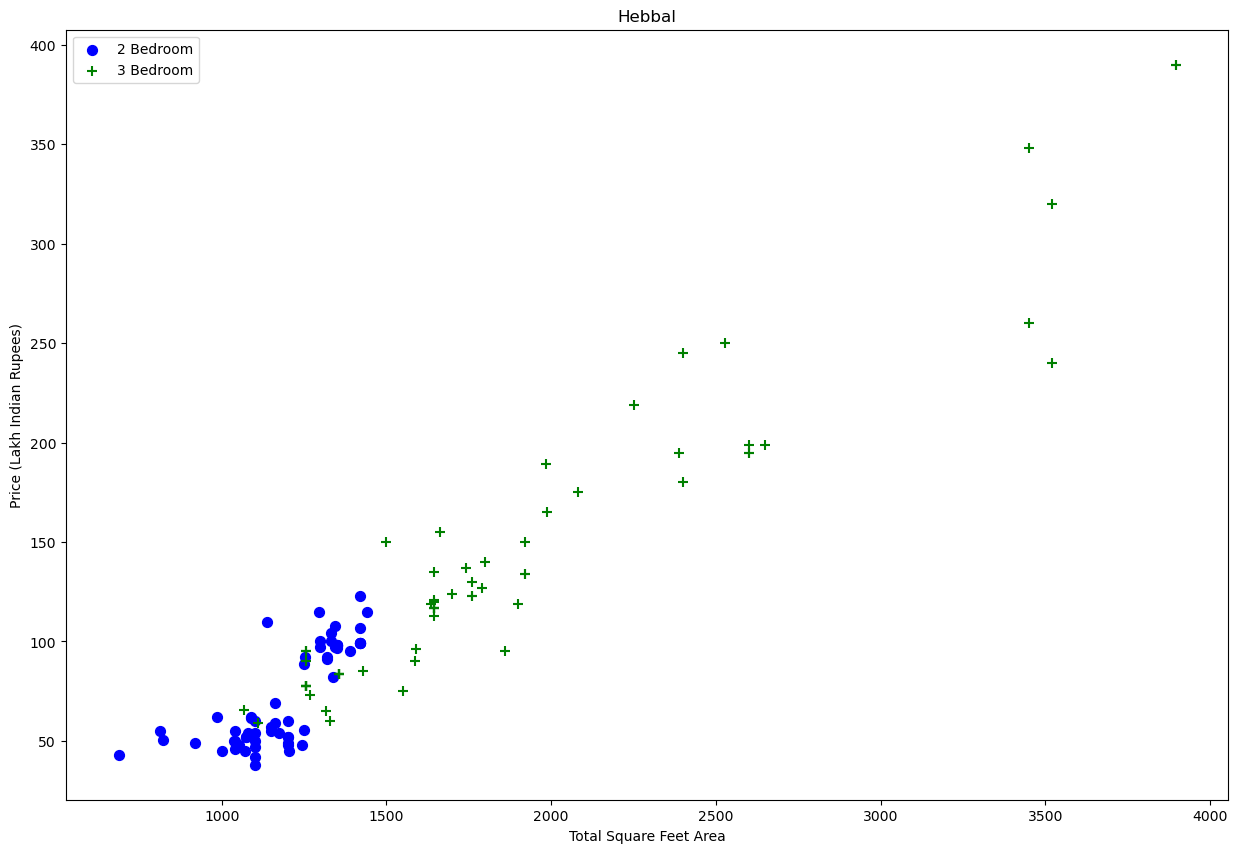

In [43]:
plot_scatter_chart(df,"Hebbal")

In [44]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bedroom'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bedroom'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices,axis='index')
df = remove_bhk_outliers(df)
df.shape

(8302, 6)

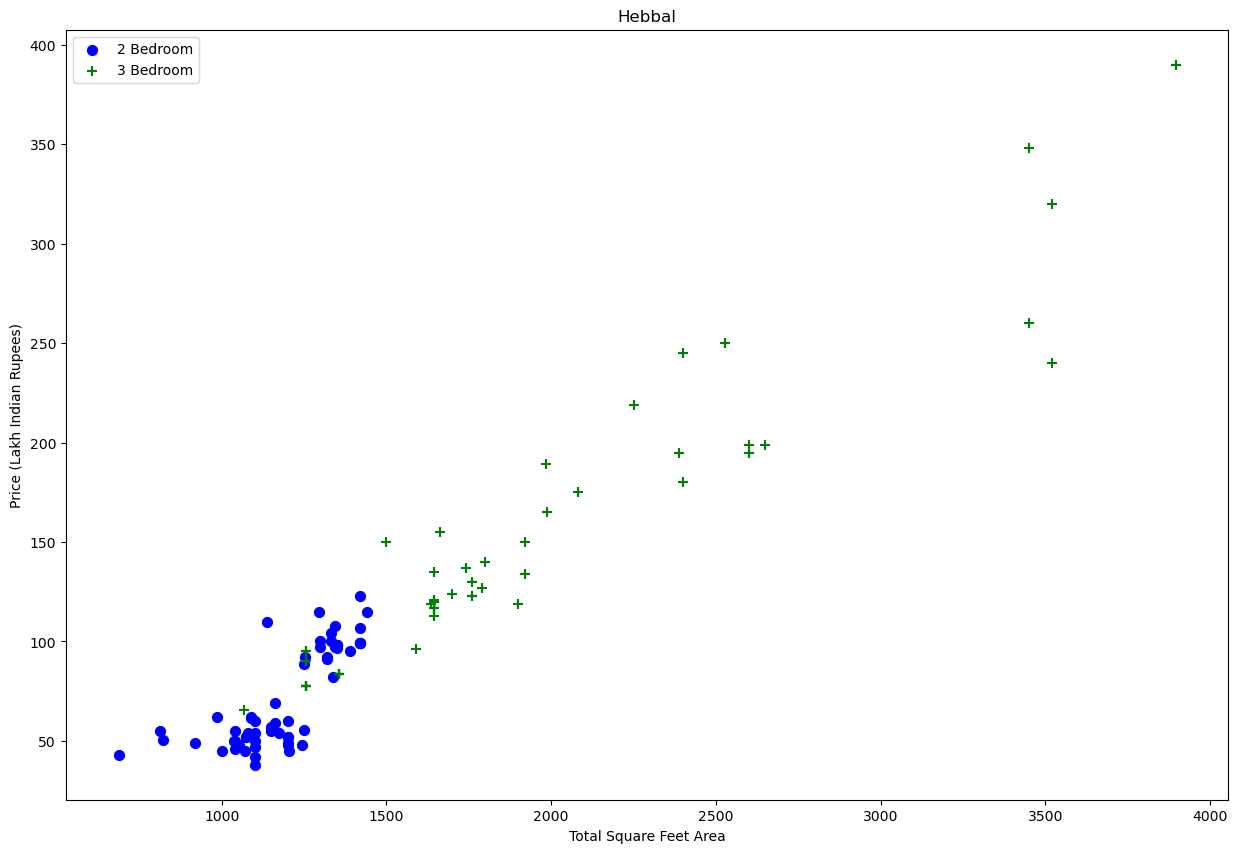

In [45]:
plot_scatter_chart(df,"Hebbal")

Text(0, 0.5, 'Count')

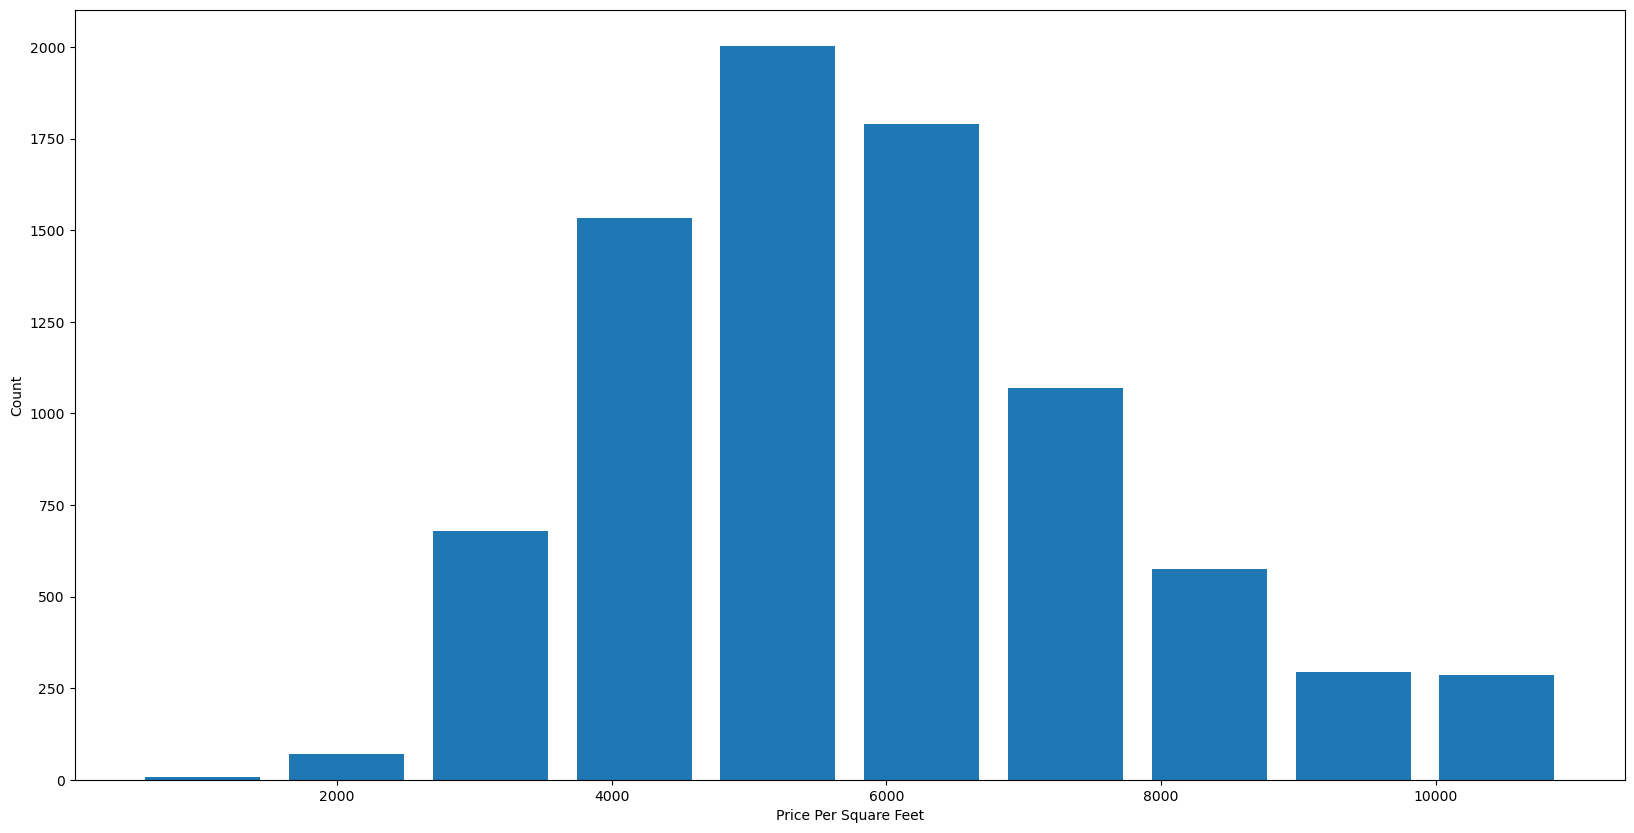

In [46]:
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

In [47]:
df.bath.unique()

array([ 2.,  3.,  4.,  5.,  1.,  8.,  6.,  7.,  9., 12., 16., 10., 13.])

Text(0, 0.5, 'Count')

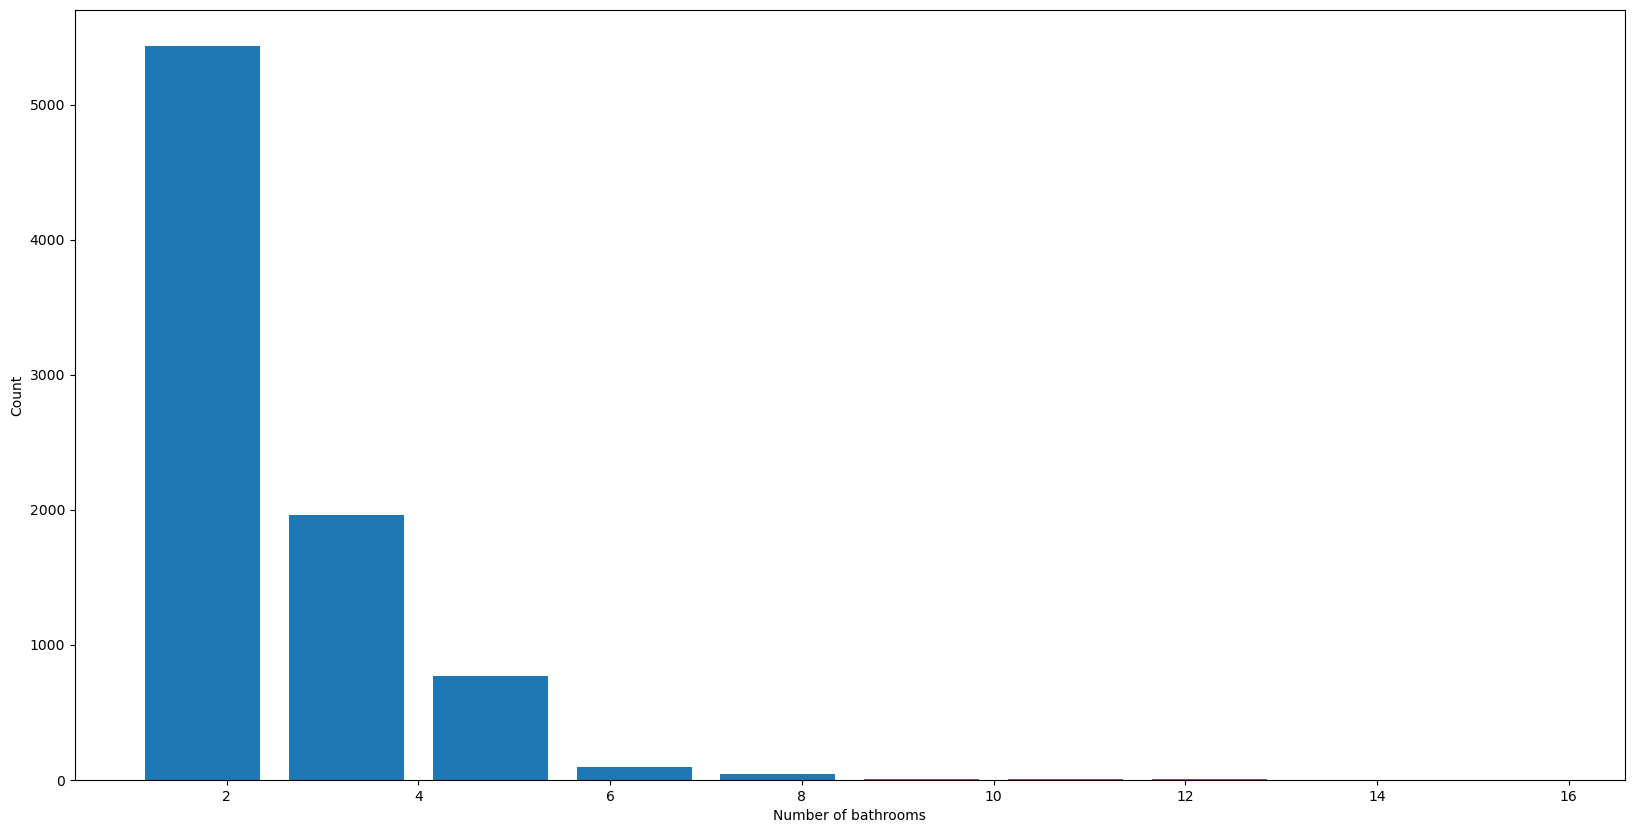

In [48]:
plt.hist(df.bath,rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [49]:
df[df.bath>10]

,location,total_sqft,bath,price,bedroom,price_per_sqft
3096,other,12000.0,12.0,525.0,10,4375.000000
3609,other,10000.0,16.0,550.0,16,5500.000000
7979,other,6000.0,12.0,150.0,11,2500.000000
8636,Neeladri Nagar,4000.0,12.0,160.0,10,4000.000000
9935,other,5425.0,13.0,275.0,13,5069.124424


In [50]:
df[df.bath > df.bedroom + 2]

,location,total_sqft,bath,price,bedroom,price_per_sqft
2620,other,11338.0,9.0,1000.0,6,8819.897689
7709,Chikkabanavar,2460.0,7.0,80.0,4,3252.032520
11366,Nagasandra,7000.0,8.0,450.0,4,6428.571429
12103,Thanisandra,1806.0,6.0,116.0,3,6423.034330


In [51]:
df = df[df.bath < df.bedroom+2]
df.shape

(8221, 6)

In [52]:
df = df.drop(['price_per_sqft'],axis='columns')
df.head(3)

,location,total_sqft,bath,price,bedroom
0,Electronic City Phase II,1056.0,2.0,39.07,2
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
